# STAT 109 — Lab 6: Binomial Tests and Normal Approximation

**Purpose:** This lab builds on Labs 1–4 and Lectures 15–16. You will test hypotheses about a proportion/probability $p$ using both the **binomial** model (exact) and the **normal approximation** (Lecture 16). You will compare when the approximation is poor vs good (conditions $np \geq 10$ and $n(1-p) \geq 10$).

------------------------------------------------------------------------

## Learning goals

- Test $H_0: p = p_0$ vs $H_a: p \neq p_0$ (two-sided) for a binomial random process.
- Plot the null distribution with `dbinom` and `geom_col`; add vertical line at the data and shade the p-value region.
- Compute the two-sided p-value with `pbinom`.
- Compute center $\mu = np$ and spread $\sigma = \sqrt{np(1-p)}$; add labeled vertical lines on the binomial plot.
- Plot the **normal approximation** (same x-axis): `dnorm` with mean $np$, sd $\sqrt{np(1-p)}$; add vertical lines at $\mu$, $\mu \pm 1\sigma$, $\mu \pm 2\sigma$, and a green line at the observed data.
- Decide if the data fall in the rejection region (e.g. beyond 2 SDs from the mean) and state the conclusion.
- Recognize when the normal approximation is **poor** vs **good** (conditions $np \geq 10$, $n(1-p) \geq 10$).

------------------------------------------------------------------------

## Setup: load ggplot2

Run the cell below so you can use `ggplot2` for plotting.

**Your task:** Load the `tidyverse` library using the `library()` function to access the plotting functions of ggplot2..

**Goal:** No error; library loads.

In [ ]:
# Solution


------------------------------------------------------------------------

## Problem 1 — Coin (small $n$: **poor** normal approximation)

**Scenario:** We flip a coin **10** times and observe **1** head. Test whether the coin is fair: $H_0: p = 0.5$ vs $H_a: p \neq 0.5$ (two-sided).

**Parts:** (a) Set $n$, $p$, observed $x$, and compute $\mu$, $\sigma$. Check $np \geq 10$ and $n(1-p) \geq 10$. (b) Binomial bar plot with vertical line at data and shaded two-sided p-value region. (c) Two-sided p-value using `pbinom`. (d) Add vertical lines at $\mu$, $\mu \pm 1\sigma$, $\mu \pm 2\sigma$ (colored/labeled) on the binomial plot. (e) Normal approximation plot (same x scale): `dnorm` curve, vertical lines at mean and $\pm 1\sigma$, $\pm 2\sigma$, and **green** line at the data. (f) Does the observed value fall in the rejection region (e.g. beyond 2 SDs)? Conclusion?

### 1(a) — Set parameters and compute center and spread

**Your task:** Define `n`, `p`, and the observed count `x_obs`. Compute `mu = n*p` and `sigma = sqrt(n*p*(1-p))`. Check whether `n*p >= 10` and `n*(1-p) >= 10` (store as logicals or print).

**Goal output:** Numbers for `mu`, `sigma`, and whether the approximation conditions hold.

In [ ]:
# Solution — fill in the 6 items
n <-
p <-
x_obs <-
mu <-
sigma <- sqrt(


# check the condition
n*p >=10
n*(1-p)>=10

mu = 5   sigma = 1.581139 
np >= 10? FALSE   n(1-p) >= 10? FALSE 


### 1(b) — Binomial bar plot with vertical line at data and shaded p-value region

**Your task:** Build a data frame of `x = 0:n` and `prob = dbinom(x, n, p)`. For the two-sided p-value, shade the bars that are in the "as or more extreme" region (both tails). Use `geom_col()` and add a vertical line at `x_obs`. Option: add a column `in_tail` that is TRUE for bars to shade (e.g. x <= x_obs or x >= cutoff for the other tail), then use `geom_col(aes(fill = in_tail))`.

**Goal:** Bar plot of null distribution with observed value marked and both tails shaded.

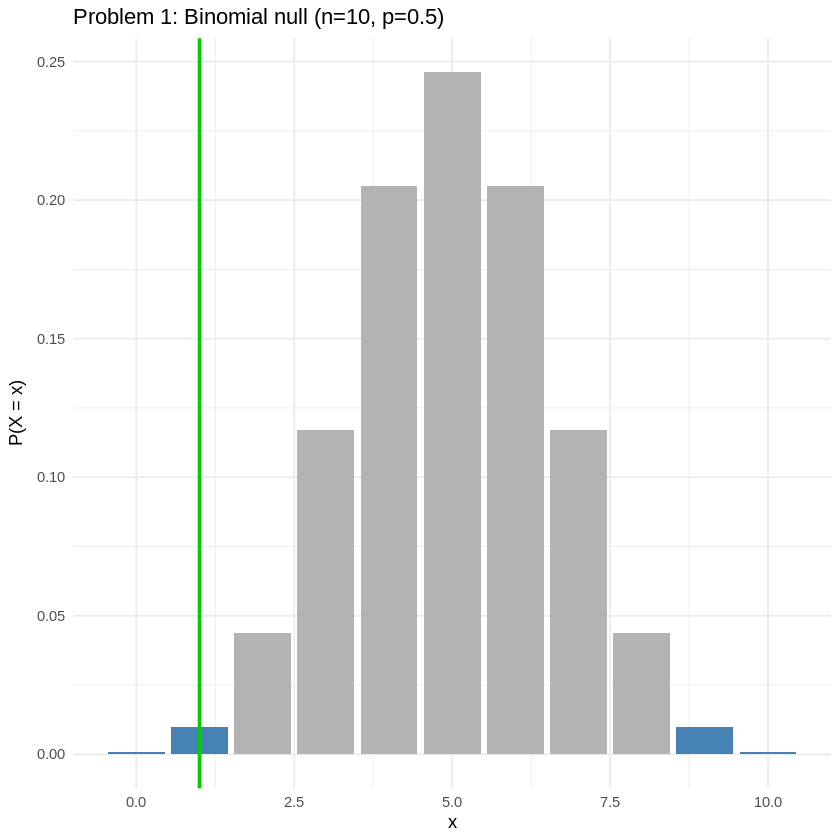

In [ ]:
# Solution — Problem 1(b)
x_vals <- 0:n
df_binom <- data.frame(x = x_vals, prob = ### fill in here)
# Two-sided: shade both tails (smaller tail doubled).
p_lo <- pbinom(x_obs, n, p)
p_hi <- 1 - pbinom(x_obs - 1, n, p)
p_tail <- min(p_lo, p_hi)
# Right-tail cutoff so that P(X >= x_high) = p_tail
x_high <- qbinom(1 - p_tail, n, p) + 1
df_binom$in_tail <- (df_binom$x <= x_obs) | (df_binom$x >= x_high)

ggplot(df_binom, aes(x = x, y = #### fill in here what should be plotted on y, fill = in_tail)) +
  geom_col() +
  geom_vline(xintercept = ### fill in here, linewidth = 1, color = "green3") +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue"), guide = "none") +
  labs(x = "x", y = "P(X = x)", title = "Problem 1: Binomial null (n=10, p=0.5)") +
  theme_minimal()

### 1(c) — Two-sided p-value using pbinom

**Your task:** Compute the two-sided p-value as `2 * min(P(X <= x_obs), P(X >= x_obs))` using `pbinom`. Print the result.

**Goal output:** A single number (the p-value).

In [ ]:
# Solution — fill in the values for pbinom to compute the P(X <=x_obs) for n and p
p_lo <- pbinom(  ##
p_hi <- 1 - pbinom(x_obs - 1, n, p)
p_value_2sided <- 2 * min(p_lo, p_hi)
p_value_2sided

Two-sided p-value = 0.02148438 


### 1(d) — Add vertical lines at mean and ±1 SD, ±2 SD on the binomial plot

**Your task:** On the same binomial bar plot (or a new one), add vertical lines at `mu`, `mu - sigma`, `mu + sigma`, `mu - 2*sigma`, `mu + 2*sigma` with different colors and labels (e.g. "μ", "μ−σ", "μ+σ", "μ−2σ", "μ+2σ").

**Goal:** Bar plot with center and spread marked.

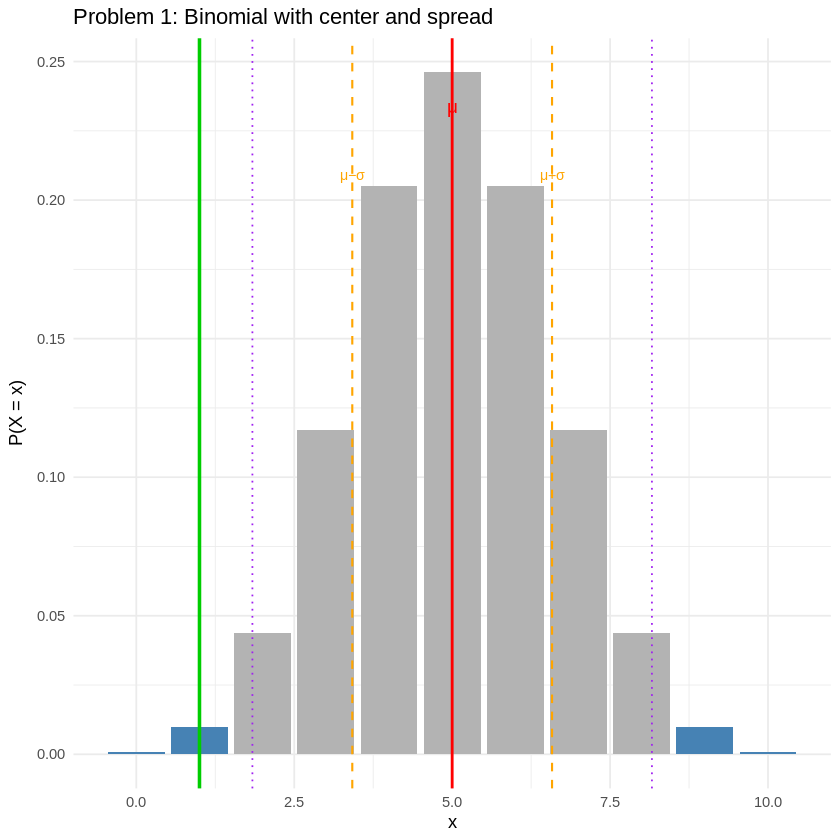

In [ ]:
# Solution — fill in the blanks
ggplot(df_binom, aes(x = x, y = prob, fill = in_tail)) +
  geom_col() +
  geom_vline(xintercept = x_obs, linewidth = 1, color = "green3") +
  geom_vline(xintercept = ### put mu=np here, linewidth = 0.8, color = "red", linetype = "solid") +
  geom_vline(xintercept = c(### put mu - sigma, mu + sigma in here), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(### put mu - 2*sigma, mu + 2*sigma in here), linewidth = 0.5, color = "purple", linetype = "dotted") +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue"), guide = "none") +
  annotate("text", x = mu, y = max(df_binom$prob)*0.95, label = "μ", color = "red", size = 4) +
  annotate("text", x = mu - sigma, y = max(df_binom$prob)*0.85, label = "μ−σ", color = "orange", size = 3) +
  annotate("text", x = mu + sigma, y = max(df_binom$prob)*0.85, label = "μ+σ", color = "orange", size = 3) +
  labs(x = "x", y = "P(X = x)", title = "Problem 1: Binomial with center and spread") +
  theme_minimal()

### 1(e) — Normal approximation plot (same x scale)

**Your task:** Create a plot with the **same x-axis** (0 to n). Draw the **normal** curve: `dnorm(x, mean = mu, sd = sigma)` over a fine grid of x values. Add vertical lines at `mu`, `mu ± sigma`, `mu ± 2*sigma` (labeled), and a **green** vertical line at `x_obs`.

**Goal:** Normal curve with mean, ±1 SD, ±2 SD, and observed value marked.

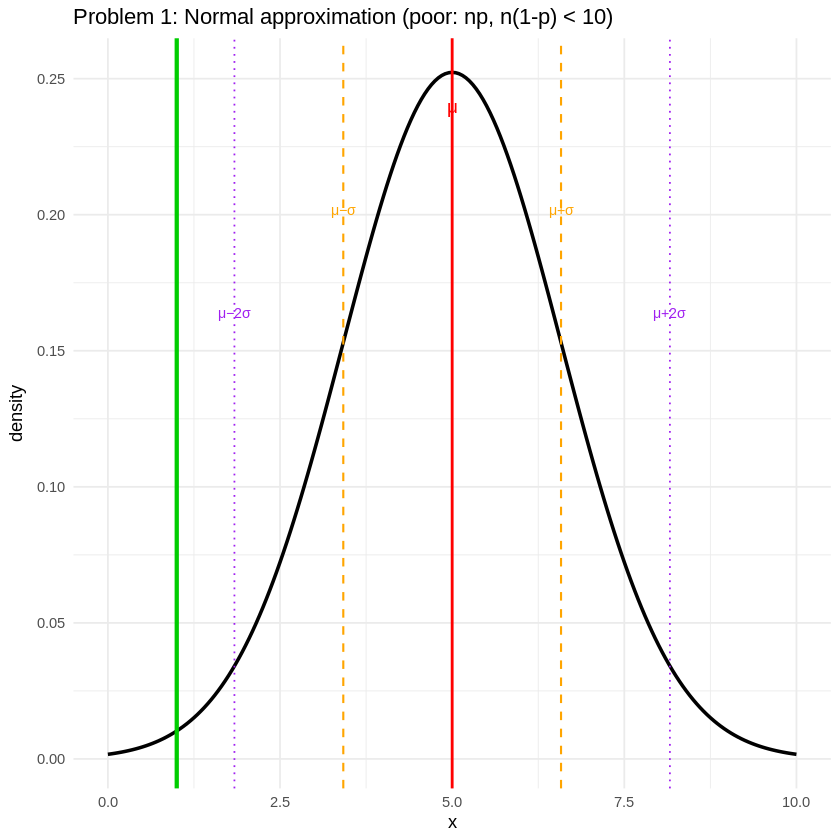

In [ ]:
# Solution — Problem 1(e)
x_fine <- seq(0, n, by = 0.05)
df_norm <- data.frame(x = x_fine, y = dnorm(x_fine, mean = mu, sd = sigma))

ggplot(df_norm, aes(x = x, y = y)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = x_obs, linewidth = 1.2, color = "green3") +
  geom_vline(xintercept = # what goes here for the center?, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = # what goes here for 1 sigma on either side of center?, linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = # what goes here for 2 sigmas on either side of center?, linewidth = 0.5, color = "purple", linetype = "dotted") +
  annotate("text", x = mu, y = max(df_norm$y)*0.95, label = "μ", color = "red", size = 4) +
  annotate("text", x = mu - sigma, y = max(df_norm$y)*0.8, label = "μ−σ", color = "orange", size = 3) +
  annotate("text", x = mu + sigma, y = max(df_norm$y)*0.8, label = "μ+σ", color = "orange", size = 3) +
  annotate("text", x = mu - 2*sigma, y = max(df_norm$y)*0.65, label = "μ−2σ", color = "purple", size = 3) +
  annotate("text", x = mu + 2*sigma, y = max(df_norm$y)*0.65, label = "μ+2σ", color = "purple", size = 3) +
  labs(x = "x", y = "density", title = "Problem 1: Normal approximation (poor: np, n(1-p) < 10)") +
  theme_minimal()

### 1(f) — Rejection region and conclusion

**Your task:** (Text answer.) Does the observed value (green line) fall **beyond 2 SDs** from the mean (i.e. in the rejection region)? State whether you **reject** or **fail to reject** $H_0$ and a one-sentence conclusion in context.

**Goal:** Short written answer.

**Solution — Problem 1(f):**

------------------------------------------------------------------------

## Problem 2 — Die (small $n$: **poor** normal approximation)

**Scenario:** We roll a die **12** times and observe **0** sixes. Test whether the die is fair for the face "6": $H_0: p = 1/6$ vs $H_a: p \neq 1/6$ (two-sided).

**Parts:** (a)–(f) as in Problem 1: parameters, binomial plot with shading and vertical line at data, two-sided p-value, center/spread lines on binomial plot, normal approximation plot with green line at data, rejection region and conclusion.

### 2(a) — Parameters and center/spread

In [ ]:
# Solution — fill in the five items and then check condition
n <-
p <-
x_obs <-
mu <-
sigma <-


mu = 2   sigma = 1.291 
np >= 10? FALSE   n(1-p) >= 10? TRUE 


### 2(b) — Binomial plot with shading and vertical line at data

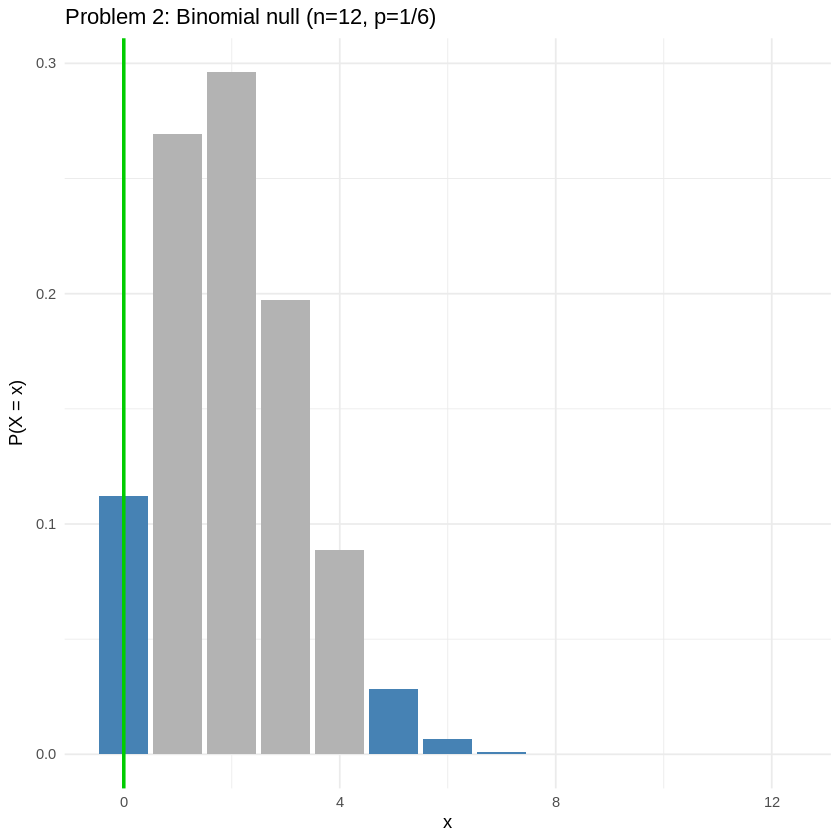

In [ ]:
# Solution — fill in one line
x_vals <- 0:n
df_binom <- # add the code to make a data frame with possbile x values and P(X=x) via dbinom
p_lo <- pbinom(x_obs, n, p)
p_hi <- 1 - pbinom(x_obs - 1, n, p)
p_tail <- min(p_lo, p_hi)
x_high <- qbinom(1 - p_tail, n, p) + 1
df_binom$in_tail <- (df_binom$x <= x_obs) | (df_binom$x >= x_high)

ggplot(df_binom, aes(x = x, y = prob, fill = in_tail)) +
  geom_col() +
  geom_vline(xintercept = x_obs, linewidth = 1, color = "green3") +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue"), guide = "none") +
  labs(x = "x", y = "P(X = x)", title = "Problem 2: Binomial null (n=12, p=1/6)") +
  theme_minimal()

### 2(c) — Two-sided p-value

In [ ]:
# Solution — fill in below
p_lo <- # fill in left tail P(X<=x) using pbinom with n and p
p_hi <- 1 - pbinom(x_obs - 1, n, p)
p_value_2sided <- 2 * min(p_lo, p_hi)
cat("Two-sided p-value =", round(p_value_2sided, 4), "\n")

Two-sided p-value = 0.2243 


### 2(d) — Binomial plot with center and spread lines

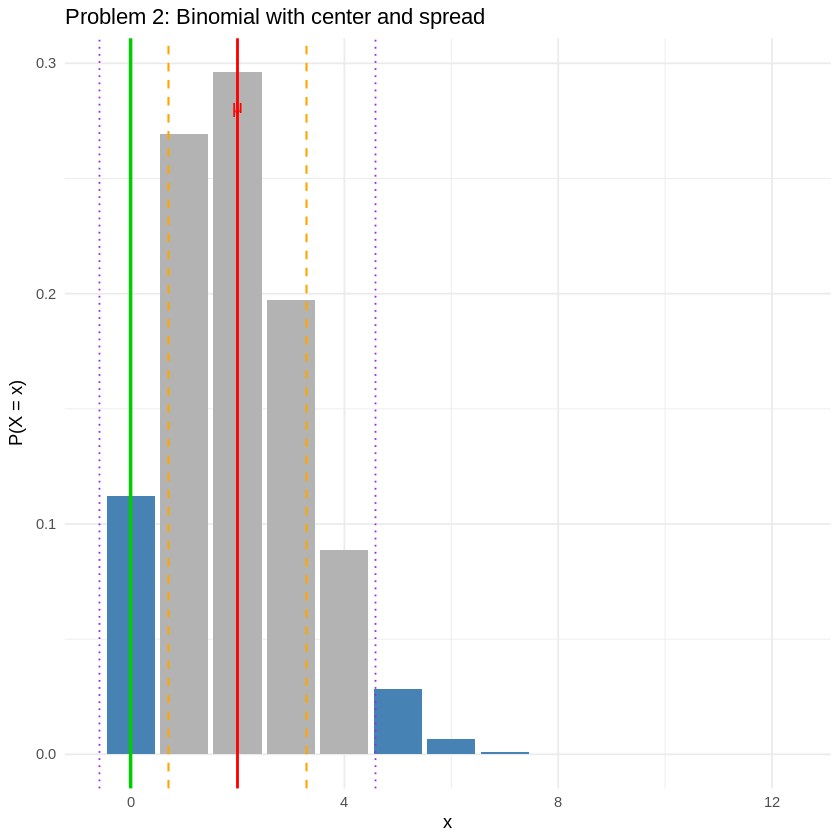

In [ ]:
# Solution — Problem 2(d)
ggplot(df_binom, aes(x = x, y = prob, fill = in_tail)) +
  geom_col() +
  geom_vline(xintercept = # fill in observed x, linewidth = 1, color = "green3") +
  geom_vline(xintercept = mu, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = c(mu - sigma, mu + sigma), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(mu - 2*sigma, mu + 2*sigma), linewidth = 0.5, color = "purple", linetype = "dotted") +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue"), guide = "none") +
  annotate("text", x = mu, y = max(df_binom$prob)*0.95, label = "μ", color = "red", size = 4) +
  labs(x = "x", y = "P(X = x)", title = "Problem 2: Binomial with center and spread") +
  theme_minimal()

### 2(e) — Normal approximation plot

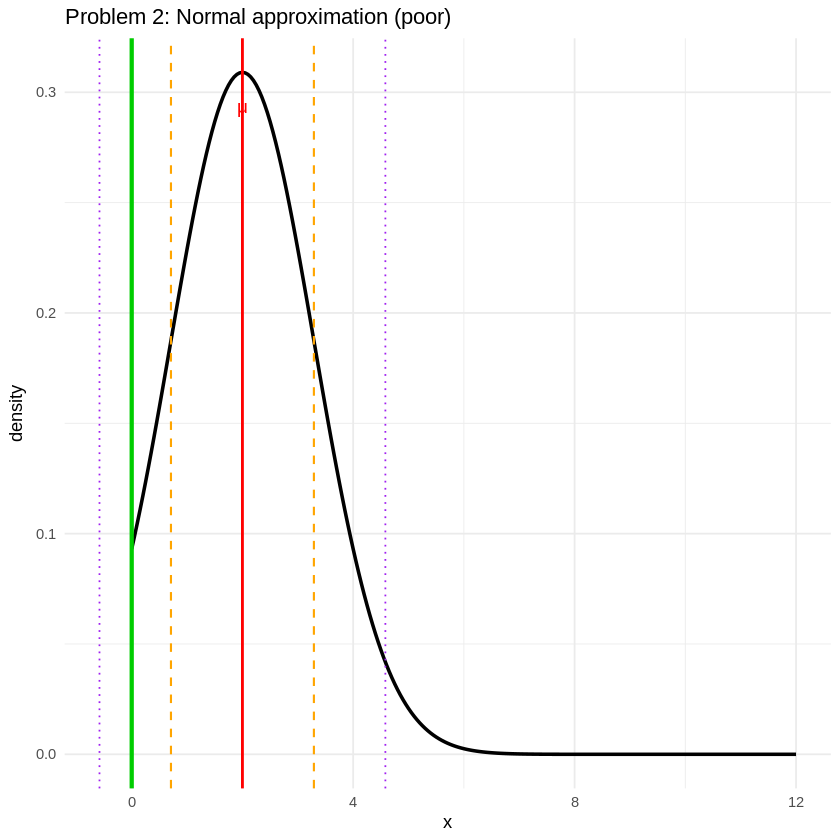

In [ ]:
# Solution — fill in the line
x_fine <- seq(0, n, by = 0.05)
df_norm <- data.frame(x = x_fine, y = # fill in normal approximation to P(X=x) using dnorm)

ggplot(df_norm, aes(x = x, y = y)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = x_obs, linewidth = 1.2, color = "green3") +
  geom_vline(xintercept = mu, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = c(mu - sigma, mu + sigma), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(mu - 2*sigma, mu + 2*sigma), linewidth = 0.5, color = "purple", linetype = "dotted") +
  annotate("text", x = mu, y = max(df_norm$y)*0.95, label = "μ", color = "red", size = 4) +
  labs(x = "x", y = "density", title = "Problem 2: Normal approximation (poor)") +
  theme_minimal()

### 2(f) — Rejection region and conclusion

**Your task:** Does the observed value fall beyond 2 SDs from the mean? Reject or fail to reject? Conclusion?

**Solution — Problem 2(f):**

------------------------------------------------------------------------

## Problem 3 — Coin (large $n$: **good** normal approximation)

**Scenario:** We flip a coin **50** times and observe **20** heads. Test $H_0: p = 0.5$ vs $H_a: p \neq 0.5$ (two-sided).

**Parts:** (a)–(f) as before. Here $np = 25$ and $n(1-p) = 25$, so the normal approximation is **good**.

### 3(a)–(f) — Full solution (parameters, binomial plot, p-value, center/spread, normal plot, conclusion)

In [ ]:
# Solution — fill in all items needed to compute the two-sided p-value via pbinom

cat("Two-sided p-value =", round(p_value_2sided, 4), "\n")

mu = 25   sigma = 3.535534 
np >= 10? TRUE   n(1-p) >= 10? TRUE 
Two-sided p-value = 0.2026 


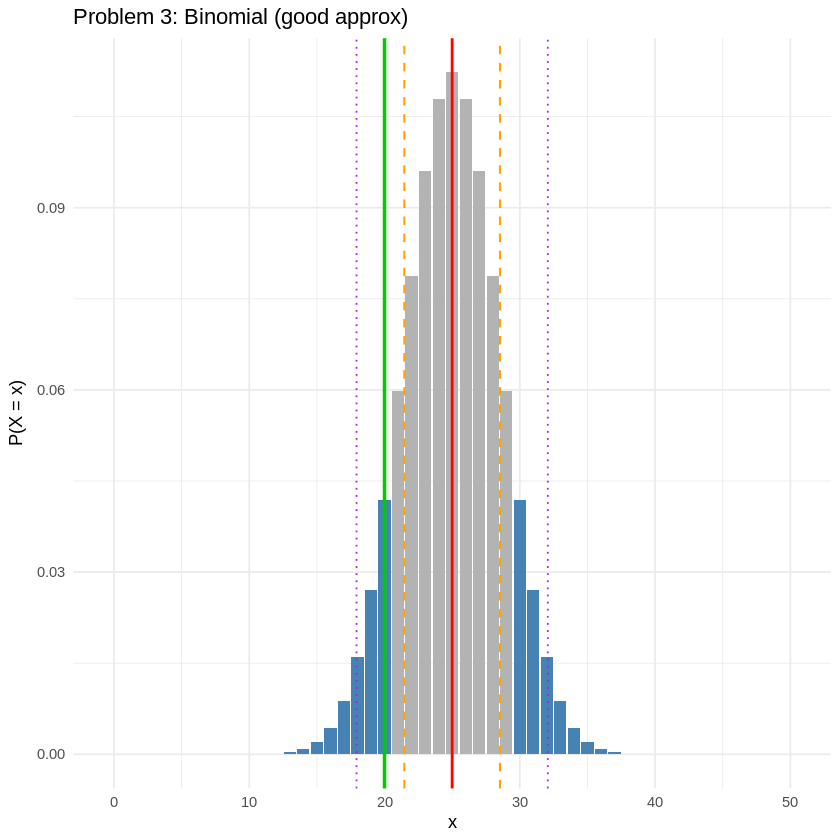

In [ ]:
# Binomial plot with shading and center/spread
x_vals <- 0:n
df_binom <- data.frame(x = x_vals, prob = dbinom(x_vals, n, p))
p_tail <- min(p_lo, p_hi)
x_high <- qbinom(1 - p_tail, n, p) + 1
df_binom$in_tail <- (df_binom$x <= x_obs) | (df_binom$x >= x_high)

ggplot(df_binom, aes(x = x, y = prob, fill = in_tail)) +
  geom_col() +
  geom_vline(xintercept = x_obs, linewidth = 1, color = "green3") +
  geom_vline(xintercept = mu, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = c(mu - sigma, mu + sigma), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(mu - 2*sigma, mu + 2*sigma), linewidth = 0.5, color = "purple", linetype = "dotted") +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue"), guide = "none") +
  labs(x = "x", y = "P(X = x)", title = "Problem 3: Binomial (good approx)") +
  theme_minimal()

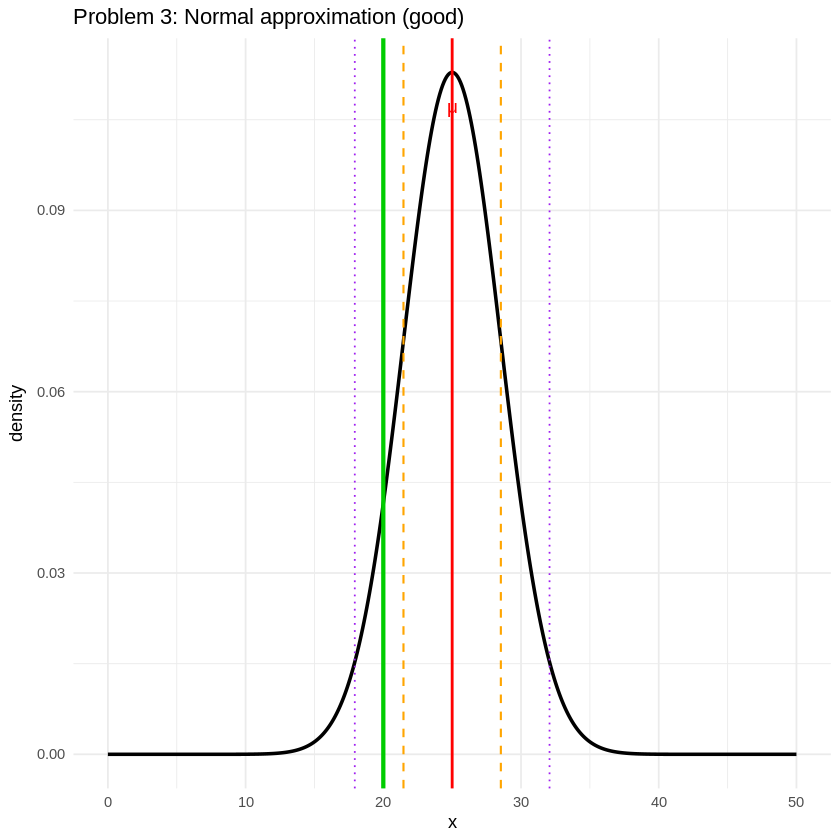

In [ ]:
# Normal approximation plot
x_fine <- seq(0, n, by = 0.1)
df_norm <- data.frame(x = x_fine, y = dnorm(x_fine, mean = mu, sd = sigma))

ggplot(df_norm, aes(x = x, y = y)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = x_obs, linewidth = 1.2, color = "green3") +
  geom_vline(xintercept = mu, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = c(mu - sigma, mu + sigma), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(mu - 2*sigma, mu + 2*sigma), linewidth = 0.5, color = "purple", linetype = "dotted") +
  annotate("text", x = mu, y = max(df_norm$y)*0.95, label = "μ", color = "red", size = 4) +
  labs(x = "x", y = "density", title = "Problem 3: Normal approximation (good)") +
  theme_minimal()

**Fill in your Conclusion** The data are/are NOT (select one) consistent with a fair coin.

------------------------------------------------------------------------

## Problem 4 — Die (large $n$: **good** normal approximation)

**Scenario:** We roll a die **60** times and observe **3** sixes. Test $H_0: p = 1/6$ vs $H_a: p \neq 1/6$ (two-sided).

**Parts:** (a)–(f). Here $np = 10$ and $n(1-p) = 50$, so the approximation is **good**. The observed 3 is well below the mean 10, so we expect to **reject** $H_0$.

In [ ]:
# Solution — Problem 4

# fill in the items to calculate a two-sided p-value using pbinom

cat("Two-sided p-value =", round(p_value_2sided, 4), "\n")

mu = 10   sigma = 2.8868 
np >= 10? TRUE   n(1-p) >= 10? TRUE 
Two-sided p-value = 0.0127 


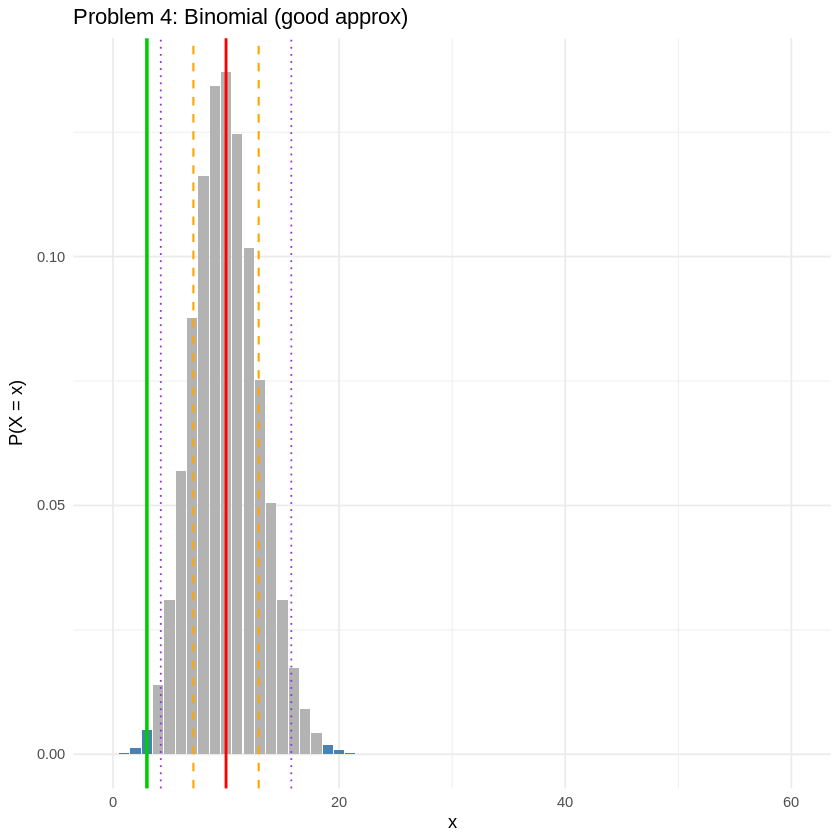

In [ ]:
# Binomial plot with shading and center/spread
x_vals <- 0:n
df_binom <- data.frame(x = x_vals, prob = dbinom(x_vals, n, p))
p_tail <- min(p_lo, p_hi)
x_high <- qbinom(1 - p_tail, n, p) + 1
df_binom$in_tail <- (df_binom$x <= x_obs) | (df_binom$x >= x_high)

ggplot(df_binom, aes(x = x, y = prob, fill = in_tail)) +
  geom_col() +
  geom_vline(xintercept = x_obs, linewidth = 1, color = "green3") +
  geom_vline(xintercept = mu, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = c(mu - sigma, mu + sigma), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(mu - 2*sigma, mu + 2*sigma), linewidth = 0.5, color = "purple", linetype = "dotted") +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue"), guide = "none") +
  labs(x = "x", y = "P(X = x)", title = "Problem 4: Binomial (good approx)") +
  theme_minimal()

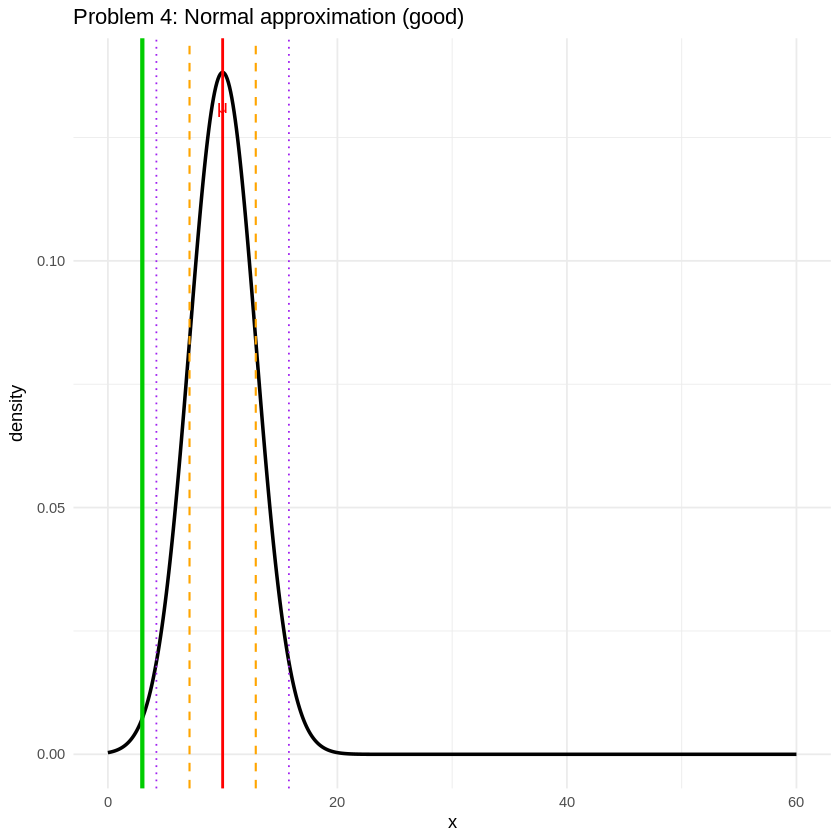

In [ ]:
# Normal approximation plot
x_fine <- seq(0, n, by = 0.1)
df_norm <- data.frame(x = x_fine, y = dnorm(x_fine, mean = mu, sd = sigma))

ggplot(df_norm, aes(x = x, y = y)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = x_obs, linewidth = 1.2, color = "green3") +
  geom_vline(xintercept = mu, linewidth = 0.8, color = "red") +
  geom_vline(xintercept = c(mu - sigma, mu + sigma), linewidth = 0.6, color = "orange", linetype = "dashed") +
  geom_vline(xintercept = c(mu - 2*sigma, mu + 2*sigma), linewidth = 0.5, color = "purple", linetype = "dotted") +
  annotate("text", x = mu, y = max(df_norm$y)*0.95, label = "μ", color = "red", size = 4) +
  labs(x = "x", y = "density", title = "Problem 4: Normal approximation (good)") +
  theme_minimal()

**Fill in your conclustion**: The data are (in)consistent with a fair die (p = 1/6); we have evidence that p ≠ 1/6 (too few sixes).

------------------------------------------------------------------------

## Summary table: check your work before turning in

| Problem | Scenario | $n$ | $p$ | $x_{\text{obs}}$ | np, n(1-p) | Approx | Reject? |
|---------|----------|-----|-----|------------------|------------|--------|--------|
| 1 | Coin | 10 | 0.5 | 1 | 5, 5 | Poor | Yes |
| 2 | Die | 12 | 1/6 | 0 | 2, 10 | Poor | No |
| 3 | Coin | 50 | 0.5 | 20 | 25, 25 | Good | No |
| 4 | Die | 60 | 1/6 | 3 | 10, 50 | Good | Yes |



Reflection:

What condition should be checked before using the normal approximation and 2 sigmas beyond the mean to perform a test of a binomial probability $p$?